## YOLO 

- YOLO는 위치추정 (BBOX) 과 종류를 출력 (속도가 매우 빠름) 
- verion이 계속 업그이드 (현재 11), model 크기도, nano, small, medium, large, extra large 등 다양
- 대학에서 시작하였으나  현재는 ultralytics 이라는 회사에서 관리 (오픈 소스) 
       



In [10]:
!pip install ultralytics 

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 16.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 828.7/828.7 kB 15.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 25.2 MB/s  0:00:02 eta 0:00:010:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [ultralytics] 3/4 [ultralytics]

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip



0: 416x640 1 person, 1 dog, 2 beds, 3.7ms
Speed: 1.2ms preprocess, 3.7ms inference, 0.5ms postprocess per image at shape (1, 3, 416, 640)
{0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant', 59

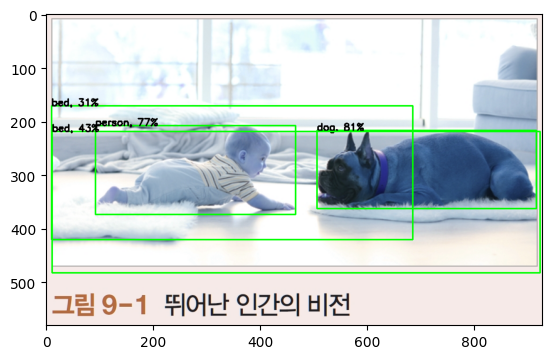

In [86]:
import numpy as np
import cv2
from ultralytics import YOLO
import torch

model = YOLO('yolo11n.pt', task = "detect")
if torch.cuda.is_available():
    model.to('cuda')
    
img_path = '그림 9-1.jpg'
img = cv2.imread(img_path)

# 추론 (Inference)
results = model([img])  # batch processing

# 결과 출력 (좌표, 확률, 클래스)
result = results[0]
print(result.names) # check the detail attributes 

dets = []
if result.boxes is not None:
    for box in result.boxes.data.tolist():
        x1, y1, x2, y2, conf, cls = box
        cv2.rectangle(img, (int(x1), int(y1)), (int(x2), int(y2)), (0, 255, 0), 2)
        cv2.putText(img, f"{result.names[cls]}, {conf*100:.0f}%", (int(x1), int(y1)), cv2.FONT_HERSHEY_SIMPLEX,  0.6, (0, 0, 0), 2)

plt.imshow(img)

##  Unet 



Using cache found in /home/gpt/.cache/torch/hub/mateuszbuda_brain-segmentation-pytorch_master


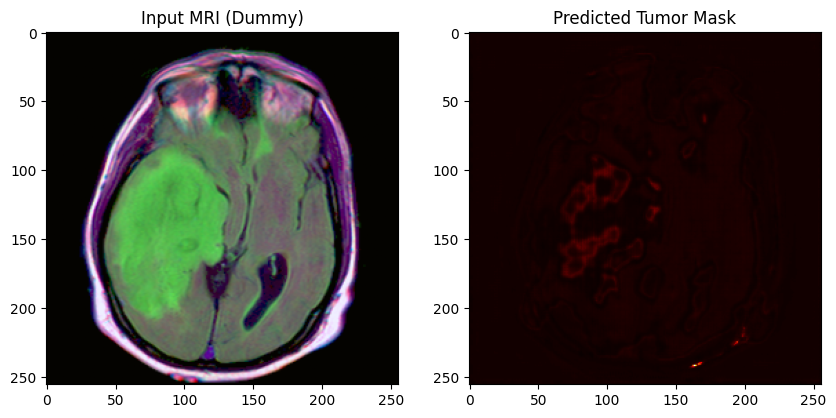

In [87]:
import torch
import matplotlib.pyplot as plt

# 1. PyTorch Hub에서 뇌 종양 세그멘테이션 U-Net 모델 로드
# (mateuszbuda의 모델을 불러옵니다)
model = torch.hub.load('mateuszbuda/brain-segmentation-pytorch', 'unet',
                       in_channels=3, out_channels=1, init_features=32, pretrained=True)
model.eval()

# 2. 영상 데이터 생성 (Batch: 1, Channel: 3, H: 256, W: 256)
# 이미지 파일을 로드하여 정규화한 텐서입니다.
#dummy_mri = torch.randn(1, 3, 256, 256)
import urllib
url, filename = ("https://github.com/mateuszbuda/brain-segmentation-pytorch/raw/master/assets/TCGA_CS_4944.png", "TCGA_CS_4944.png")
try: 
    urllib.URLopener().retrieve(url, filename)
except: 
    urllib.request.urlretrieve(url, filename)
    
# OpenCV로 읽기
img = cv2.imread(filename)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # BGR을 RGB로 변경

# PyTorch 모델 입력용 전처리
# (H, W, C) -> (C, H, W)로 변경하고 0~1 사이로 정규화
mri_tensor = img.transpose(2, 0, 1) / 255.0 
mri_tensor = torch.FloatTensor(mri_tensor).unsqueeze(0) # 배치 차원 추가 (1, 3, H, W)

# 3. 추론 (Segmentation)
with torch.no_grad():
    output = model(mri_tensor)

# 4. 시각화
# 출력값은 확률값으로 변환하기 위해 sigmoid를 통과시키기도 합니다.
mask = torch.sigmoid(output).squeeze().cpu().numpy()

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Input MRI (Dummy)")
plt.imshow(mri_tensor[0].permute(1, 2, 0)) # [C, H, W] -> [H, W, C]

plt.subplot(1, 2, 2)
plt.title("Predicted Tumor Mask")
plt.imshow(mask, cmap='hot')
plt.show()

## 얼굴 인식 

- 일굴 인식은  "얼굴검출" => "얼굴정렬" => "피쳐추출" => "유사도 계산"의 단게를 거치는 상당히 복잡한 과정
- 여기서는 검출과 정렬에 대한 부분은 이미 처리되었다고 가정하고 피쳐벡터 추출과 유사도 검사하는 부분만을 제시
- 얼굴 검출과 정럴 관련해서는 dblib이라는 패키지를 활용  

### 데모 예 

두명의 얼굴 데이터를 비교 (여러명의 경우로 확장 가능)
   - 2a: 2번 사람의 등록 사진
   - 5a: 5번 사람의 등록 사진
   - 2b: 2번 사진의 현장 시진


- 백본 네트워크:
    - model weights file을 다운 받을수 있는 곳
        - https://github.com/daovietanh190499/face_rec/releases/download/v1.0.0/backbone_ir50_ms1m_epoch120.pth
    - backbone_ir50: 백본 네트워크로 IR-50(Improved ResNet-50) 구조 사용
    - ms1m: MS-Celeb-1M이라는 거대한 얼굴 데이터셋(약 100만 명의 얼굴 이미지)으로 학습
    - epoch120: 총 120 에폭(Epoch) 동안 학습을 완료한 최종 체크포인트 파일입니다.

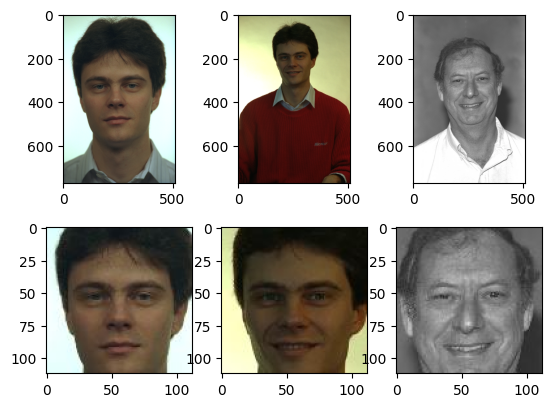

In [70]:
# Face data example (FERET)
import matplotlib.pyplot as plt
import cv2
f2a  = "00002_940128_fa.png"  # before alignement
f2b  = "00002_931230_fb.png"
f5a  = "00005_930831_fa.png"
f2a_aligned  = "00002_940128_fa.jpg"  # after alignment
f2b_aligned  = "00002_931230_fb.jpg"
f5a_aligned  = "00005_930831_fa.jpg"

for i, p in enumerate([f2a, f2b, f5a, f2a_aligned, f2b_aligned, f5a_aligned]):
    img = cv2.imread(p)
    plt.subplot(2,3, i+1)
    plt.imshow(img[:,:,::-1])


In [45]:
# Original code
# https://github.com/ZhaoJ9014/face.evoLVe.PyTorch/blob/master/backbone/model_irse.py

from collections import namedtuple

import torch
import torch.nn as nn

class bottleneck_IR(nn.Module):
    def __init__(self, in_channel, depth, stride):
        super(bottleneck_IR, self).__init__()
        if in_channel == depth:
            self.shortcut_layer = nn.MaxPool2d(1, stride)
        else:
            self.shortcut_layer = nn.Sequential(
                nn.Conv2d(in_channel, depth, (1, 1), stride, bias=False),
                nn.BatchNorm2d(depth),
            )
        self.res_layer = nn.Sequential(
            nn.BatchNorm2d(in_channel),
            nn.Conv2d(in_channel, depth, (3, 3), (1, 1), 1, bias=False),
            nn.PReLU(depth),
            nn.Conv2d(depth, depth, (3, 3), stride, 1, bias=False),
            nn.BatchNorm2d(depth),
        )

    def forward(self, x):
        shortcut = self.shortcut_layer(x)
        res = self.res_layer(x)
        return res + shortcut


class Bottleneck(namedtuple("Block", ["in_channel", "depth", "stride"])):
    """A named tuple describing a ResNet block."""


def get_block(in_channel, depth, num_units, stride=2):
    return [Bottleneck(in_channel, depth, stride)] + [
        Bottleneck(depth, depth, 1) for i in range(num_units - 1)
    ]


class Backbone(nn.Module):
    def __init__(self, input_size):
        super(Backbone, self).__init__()
        assert input_size[0] in [
            112,
            224,
        ], "input_size should be [112, 112] or [224, 224]"

        blocks = [
            get_block(in_channel=64, depth=64, num_units=3),
            get_block(in_channel=64, depth=128, num_units=4),
            get_block(in_channel=128, depth=256, num_units=14),
            get_block(in_channel=256, depth=512, num_units=3),
        ]
        unit_module = bottleneck_IR

        self.input_layer = nn.Sequential(
            nn.Conv2d(3, 64, (3, 3), 1, 1, bias=False), nn.BatchNorm2d(64), nn.PReLU(64),
        )
        if input_size[0] == 112:
            self.output_layer = nn.Sequential(
                nn.BatchNorm2d(512),
                nn.Dropout(),
                nn.Flatten(),
                nn.Linear(512 * 7 * 7, 512),
                nn.BatchNorm1d(512),
            )
        else:
            self.output_layer = nn.Sequential(
                nn.BatchNorm2d(512),
                nn.Dropout(),
                nn.Flatten(),
                nn.Linear(512 * 14 * 14, 512),
                nn.BatchNorm1d(512),
            )

        modules = []
        for block in blocks:
            for bottleneck in block:
                modules.append(
                    unit_module(
                        bottleneck.in_channel, bottleneck.depth, bottleneck.stride,
                    ),
                )
        self.body = nn.Sequential(*modules)

    def forward(self, x):
        x = self.input_layer(x)
        x = self.body(x)
        x = self.output_layer(x)
        return x

In [51]:
#import cv2
#import numpy as np
import torch
import torch.utils.data as data
import torchvision.datasets as datasets
import torch.nn.functional as F
import torchvision.transforms as transforms
from tqdm import tqdm

embedding_size=512
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
batch_size = 1 
input_size = (112, 112)  # the model's image input size

# load arcgface backbone model
arcFace = Backbone(input_size)
checkpoint_path = os.path.join("checkpoint", "backbone_ir50_ms1m_epoch120.pth")
assert os.path.exists(checkpoint_path)
arcFace.load_state_dict(torch.load(checkpoint_path, weights_only=False))
arcFace.to(device)
arcFace.eval()


Backbone(
  (input_layer): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): PReLU(num_parameters=64)
  )
  (output_layer): Sequential(
    (0): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (1): Dropout(p=0.5, inplace=False)
    (2): Flatten(start_dim=1, end_dim=-1)
    (3): Linear(in_features=25088, out_features=512, bias=True)
    (4): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (body): Sequential(
    (0): bottleneck_IR(
      (shortcut_layer): MaxPool2d(kernel_size=1, stride=2, padding=0, dilation=1, ceil_mode=False)
      (res_layer): Sequential(
        (0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (2): PReLU(num_parame

In [79]:
import torch
from PIL import Image
import torchvision.transforms as transforms
def preprocess_image(image_path, input_size=(112, 112)):
    """
    ArcFace 모델 입력을 위해 단일 이미지를 로드하고 전처리
    Args:
        image_path (str): 이미지 파일 경로
        input_size (tuple): 모델이 요구하는 입력 크기 (기본값: 112x112)
    Returns:
        torch.Tensor: 모델에 바로 입력 가능한 4D Tensor [1, 3, H, W]
    """
    # 1. 이미지 로드 및 RGB 변환 (채널 수 맞추기)
    try:
        img = Image.open(image_path).convert('RGB')  # make RGB if gray 
    except Exception as e:
        print(f"이미지를 불러오는 중 오류 발생: {e}")
        return None

    # 2. 기존 Dataset의 transform 로직 적용
    # resize 비율 계산 (112 기준 원래 크기 비율 유지)
    resize_h = int(128 * input_size[0] / 112)
    resize_w = int(128 * input_size[1] / 112)
    
    transform = transforms.Compose([
        transforms.Resize([resize_h, resize_w]),
        transforms.CenterCrop([input_size[0], input_size[1]]),
        transforms.ToTensor(),
        # ArcFace는 주로 [-1, 1] 범위로 정규화합니다. (mean=0.5, std=0.5)
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
    ])
    
    # 3. 전처리 적용 -> 결과는 [3, H, W] 형태의 3D Tensor
    img_tensor = transform(img)
    
    # 4. 차원 확장 (Unsqueeze) -> [1, 3, H, W] 형태의 4D Tensor로 변환 (Batch size = 1)
    img_tensor = img_tensor.unsqueeze(0)
    
    return img_tensor
    
f2a_tensor = preprocess_image(f2a_aligned, input_size=(112, 112))
f2b_tensor = preprocess_image(f2b_aligned, input_size=(112, 112))
f5a_tensor = preprocess_image(f5a_aligned, input_size=(112, 112))

In [80]:
# get embedding for each face
with torch.no_grad(): 
    
   embedding_2a = F.normalize(arcFace(f2a_tensor.to(device))).cpu()
   embedding_2b = F.normalize(arcFace(f2b_tensor.to(device))).cpu()
   embedding_5a = F.normalize(arcFace(f5a_tensor.to(device))).cpu()
   embedding_2a = embedding_2a.squeeze()
   embedding_2b = embedding_2b.squeeze()    
   embedding_5a = embedding_5a.squeeze()

In [83]:
# 1. Cosine Similarity 계산
cos_sim_2a_2b = F.cosine_similarity(embedding_2a, embedding_2b, dim=0).item()
cos_sim_5a_2b = F.cosine_similarity(embedding_5a, embedding_2b, dim=0).item()
print(f"cos-sim: same {cos_sim_2a_2b:.4f}, diff: {cos_sim_5a_2b:.4f}")
# 2. MSE (Mean Squared Error) 계산
mse_2a_2b = F.mse_loss(embedding_2a, embedding_2b).item()
mse_5a_2b = F.mse_loss(embedding_5a, embedding_2b).item()
print(f"MSE: same:{mse_2a_2b:.6f}, diff:{mse_5a_2b:.6f}")

cos-sim: same 0.7803, diff: -0.1397
MSE: same:0.000858, diff:0.004452


## 끝 